In [2]:
!pip install torch torchvision
!pip install opencv-python
!pip install selectivesearch
!pip install tqdm
!pip install matplotlib

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from torchvision.models import vgg16
from torchvision.models.detection import fasterrcnn_resnet50_fpn

import cv2
import selectivesearch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

In [4]:
# Manually download PASCAL VOC 2012 dataset from kaggle::
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"richavasudeva","key":"431836916cac4626117dc00e2b6adc40"}'}

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d aladdinpersson/pascal-voc-dataset-used-in-yolov3-video
!unzip pascal-voc-dataset-used-in-yolov3-video.zip

Streaming output truncated to the last 5000 lines.
  inflating: PASCAL_VOC/labels/2009_004289.txt  
  inflating: PASCAL_VOC/labels/2009_004290.txt  
  inflating: PASCAL_VOC/labels/2009_004291.txt  
  inflating: PASCAL_VOC/labels/2009_004295.txt  
  inflating: PASCAL_VOC/labels/2009_004298.txt  
  inflating: PASCAL_VOC/labels/2009_004300.txt  
  inflating: PASCAL_VOC/labels/2009_004301.txt  
  inflating: PASCAL_VOC/labels/2009_004303.txt  
  inflating: PASCAL_VOC/labels/2009_004307.txt  
  inflating: PASCAL_VOC/labels/2009_004308.txt  
  inflating: PASCAL_VOC/labels/2009_004309.txt  
  inflating: PASCAL_VOC/labels/2009_004312.txt  
  inflating: PASCAL_VOC/labels/2009_004315.txt  
  inflating: PASCAL_VOC/labels/2009_004316.txt  
  inflating: PASCAL_VOC/labels/2009_004317.txt  
  inflating: PASCAL_VOC/labels/2009_004319.txt  
  inflating: PASCAL_VOC/labels/2009_004322.txt  
  inflating: PASCAL_VOC/labels/2009_004323.txt  
  inflating: PASCAL_VOC/labels/2009_004324.txt  
  inflating: PASCA

In [7]:
!ls
!ls PASCAL_VOC

kaggle.json  pascal-voc-dataset-used-in-yolov3-video.zip
PASCAL_VOC   sample_data
100examples.csv  2examples.csv	images	test.csv
1examples.csv	 8examples.csv	labels	train.csv


In [8]:
import os
import torch
import cv2
import numpy as np
from torch.utils.data import Dataset

class VOCDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root = root_dir
        self.transform = transform

        self.img_dir = os.path.join(root_dir, "images")
        self.label_dir = os.path.join(root_dir, "labels")

        self.images = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        label_path = os.path.join(self.label_dir, self.images[idx].replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.strip().split())

                    # Convert YOLO format to Pascal VOC format
                    x1 = int((x - bw/2) * w)
                    y1 = int((y - bh/2) * h)
                    x2 = int((x + bw/2) * w)
                    y2 = int((y + bh/2) * h)

                    boxes.append([x1, y1, x2, y2])
                    labels.append(int(cls))

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels

        img = torch.tensor(img / 255., dtype=torch.float32).permute(2,0,1)

        return img, target

In [9]:
dataset = VOCDataset("PASCAL_VOC")

print("Total images:", len(dataset))

Total images: 43223


In [10]:
#Reducing images::
from torch.utils.data import Subset

dataset = Subset(dataset, range(200))  # use only 200 images
print("Using images:", len(dataset))

Using images: 200


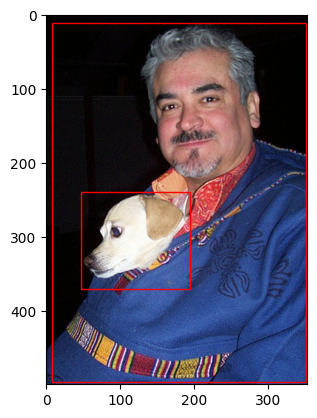

In [11]:
#Sample images ::
import matplotlib.pyplot as plt

img, target = dataset[0]

plt.imshow(img.permute(1,2,0))
for box in target["boxes"]:
    x1,y1,x2,y2 = box
    rect = plt.Rectangle((x1,y1), x2-x1, y2-y1,
                         fill=False, color="red")
    plt.gca().add_patch(rect)

plt.show()

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [13]:
#Selective Search:
!pip install selectivesearch

import selectivesearch

def get_region_proposals(image):
    # Move the tensor to CPU before converting to numpy
    img = image.cpu().permute(1,2,0).numpy()
    img = (img * 255).astype("uint8")

    _, regions = selectivesearch.selective_search(
        img, scale=500, sigma=0.9, min_size=10
    )

    proposals = []
    for r in regions:
        x,y,w,h = r['rect']
        proposals.append([x,y,x+w,y+h])

    return proposals[:2000]

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


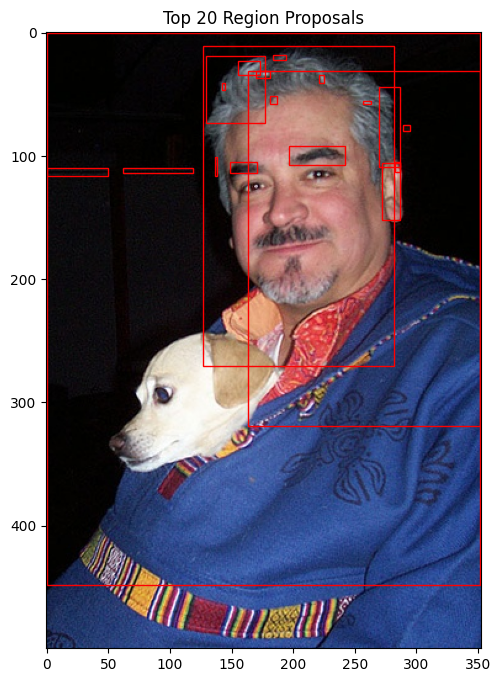

In [14]:
#TOP 20 purposals::
import matplotlib.pyplot as plt

img, target = dataset[0]
proposals = get_region_proposals(img)

plt.figure(figsize=(8,8))
plt.imshow(img.permute(1,2,0))

for box in proposals[:20]:
    x1,y1,x2,y2 = box
    rect = plt.Rectangle((x1,y1), x2-x1, y2-y1,
                         fill=False, color='red')
    plt.gca().add_patch(rect)

plt.title("Top 20 Region Proposals")
plt.show()

In [15]:
#VGG16
import torchvision.models as models
import torch.nn as nn
import torchvision.transforms as T

vgg = models.vgg16(pretrained=True)
vgg.classifier = nn.Sequential(*list(vgg.classifier.children())[:-1])
vgg = vgg.to(device)
vgg.eval()

resize = T.Resize((224,224))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 169MB/s]


In [16]:
def extract_features(image, proposals):
    features = []

    for box in proposals:
        x1,y1,x2,y2 = box

        region = image[:, y1:y2, x1:x2]
        if region.shape[1] == 0 or region.shape[2] == 0:
            continue

        region = resize(region)
        region = region.unsqueeze(0).to(device)

        with torch.no_grad():
            feat = vgg(region)

        features.append(feat.cpu())

    return torch.cat(features)

In [17]:
#LAbel pruposals that is IOU>0.5::
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)

In [18]:
def prepare_training_sample(image, target):
    proposals = get_region_proposals(image)
    features = extract_features(image, proposals)

    labels = []

    for prop in proposals[:len(features)]:
        max_iou = 0
        for gt in target["boxes"]:
            iou = compute_iou(prop, gt.tolist())
            max_iou = max(max_iou, iou)

        if max_iou > 0.5:
            labels.append(1)
        else:
            labels.append(0)

    return features, torch.tensor(labels)

In [19]:
classifier = nn.Linear(4096, 2).to(device)
optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [20]:
for epoch in range(2):
    total_loss = 0

    for i in range(20):  # only first 20 images
        img, target = dataset[i]
        img = img.to(device)

        features, labels = prepare_training_sample(img, target)

        features = features.to(device)
        labels = labels.to(device)

        outputs = classifier(features)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 9.662326633930206
Epoch: 1 Loss: 5.671457752585411


In [21]:
#Bounding Box Regression::
bbox_regressor = nn.Linear(4096, 4).to(device)
reg_optimizer = torch.optim.Adam(bbox_regressor.parameters(), lr=1e-4)
reg_loss = nn.SmoothL1Loss()

In [22]:
#Testing the above boxes::
from torchvision.ops import nms

def apply_nms(boxes, scores, threshold=0.3):
    boxes = torch.tensor(boxes, dtype=torch.float32)
    scores = torch.tensor(scores)
    keep = nms(boxes, scores, threshold)
    return keep

In [23]:
def draw_boxes(image, boxes):
    plt.figure(figsize=(8,8))
    plt.imshow(image.permute(1,2,0))

    for box in boxes:
        x1,y1,x2,y2 = box
        rect = plt.Rectangle((x1,y1),
                             x2-x1, y2-y1,
                             fill=False, color='green')
        plt.gca().add_patch(rect)
    plt.show()

In [24]:
#Evaluation of the above models::
def evaluate_iou(pred_boxes, gt_boxes):
    scores = []
    for p in pred_boxes:
        for g in gt_boxes:
            scores.append(compute_iou(p, g.tolist()))
    return sum(scores)/len(scores)


In [25]:
from sklearn.metrics import average_precision_score

def compute_map(y_true, y_scores):
    return average_precision_score(y_true, y_scores)

In [26]:
#Faster RCNN:
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn

faster_model = fasterrcnn_resnet50_fpn(pretrained=True)
faster_model = faster_model.to(device)
faster_model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 170MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [27]:
img, _ = dataset[0]
img = img.to(device)

with torch.no_grad():
    prediction = faster_model([img])

print(prediction[0]["boxes"][:5])

tensor([[ 20.9900,  10.7039, 353.0000, 500.0000],
        [141.4331, 198.0035, 268.5773, 323.6162],
        [ 51.6462, 236.0260, 192.5390, 355.9097],
        [ 75.3881,   7.0125, 338.2653, 299.4256],
        [  1.6541, 142.9946, 353.0000, 493.2052]], device='cuda:0')


In [28]:
#Apllying regression to the boxes:
def apply_regression(box, delta):
    px, py, pw, ph = box_to_center(box)
    tx, ty, tw, th = delta

    gx = tx * pw + px
    gy = ty * ph + py
    gw = pw * torch.exp(tw)
    gh = ph * torch.exp(th)

    x1 = gx - gw/2
    y1 = gy - gh/2
    x2 = gx + gw/2
    y2 = gy + gh/2

    return [x1.item(), y1.item(), x2.item(), y2.item()]

In [29]:
from torchvision.ops import nms
import torch.nn.functional as F

def rcnn_inference(image, use_regression=False):
    proposals = get_region_proposals(image)
    features = extract_features(image, proposals).to(device)

    with torch.no_grad():
        cls_scores = F.softmax(classifier(features), dim=1)
        reg_deltas = bbox_regressor(features)

    scores = cls_scores[:,1]  # positive class
    keep = scores > 0.7

    boxes = []
    confs = []

    for i, k in enumerate(keep):
        if k:
            box = proposals[i]
            if use_regression:
                box = apply_regression(box, reg_deltas[i])
            boxes.append(box)
            confs.append(scores[i].item())

    if len(boxes) == 0:
        return []

    keep_idx = nms(torch.tensor(boxes, dtype=torch.float32),
                   torch.tensor(confs), 0.3)

    final_boxes = [boxes[i] for i in keep_idx]

    return final_boxes

In [30]:
def evaluate_image(image, target, use_regression=False):
    pred_boxes = rcnn_inference(image, use_regression)
    gt_boxes = target["boxes"]

    if len(pred_boxes) == 0:
        return 0

    ious = []
    for p in pred_boxes:
        for g in gt_boxes:
            ious.append(compute_iou(p, g.tolist()))

    return sum(ious) / len(ious)

In [31]:
from sklearn.metrics import average_precision_score

def compute_dataset_map(use_regression=False):
    all_scores = []
    all_labels = []

    for i in range(30):   # small subset
        img, target = dataset[i]
        proposals = get_region_proposals(img)
        features = extract_features(img, proposals).to(device)

        with torch.no_grad():
            scores = torch.softmax(classifier(features), dim=1)[:,1]

        for j, prop in enumerate(proposals[:len(scores)]):
            max_iou = 0
            for gt in target["boxes"]:
                max_iou = max(max_iou, compute_iou(prop, gt.tolist()))

            label = 1 if max_iou > 0.5 else 0
            all_labels.append(label)
            all_scores.append(scores[j].item())

    return average_precision_score(all_labels, all_scores)

In [32]:
print("Evaluating R-CNN without regression...")
map_no_reg = compute_dataset_map(use_regression=False)

print("Evaluating R-CNN with regression...")
map_with_reg = compute_dataset_map(use_regression=True)

print("mAP without regression:", map_no_reg)
print("mAP with regression:", map_with_reg)

Evaluating R-CNN without regression...


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Evaluating R-CNN with regression...


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


mAP without regression: 0.08795962995969567
mAP with regression: 0.08795962995969567


In [33]:
def evaluate_faster_rcnn():
    all_scores = []
    all_labels = []

    for i in range(30):
        img, target = dataset[i]
        img_gpu = img.to(device)

        with torch.no_grad():
            pred = faster_model([img_gpu])[0]

        for box, score in zip(pred["boxes"], pred["scores"]):
            max_iou = 0
            for gt in target["boxes"]:
                max_iou = max(max_iou, compute_iou(box.cpu().tolist(), gt.tolist()))

            label = 1 if max_iou > 0.5 else 0
            all_labels.append(label)
            all_scores.append(score.item())

    return average_precision_score(all_labels, all_scores)

map_faster = evaluate_faster_rcnn()
print("Faster R-CNN mAP:", map_faster)

Faster R-CNN mAP: 0.5814909060222411
